# Hermite-Gaussian multimode sorter

This tutorial demonstrates the inverse design of a multi-plane diffractive optical system
that transforms spatially separated Gaussian beams into copropagating Hermite-Gaussian modes.
This canonical mode sorting problem has applications in mode-division multiplexing
for telecommunications and multimode fiber imaging.

The approach presented here builds on the work of Carpenter and Fontaine, who demonstrated
at CLEO/Europe in **June 2017** [1] an efficient mapping from triangular Gaussian beam arrays
to Laguerre-Gaussian modes (45 modes) using a remarkably low number of phase planes. This work
was significantly scaled up in their Nature Communications paper [2], demonstrating high-fidelity
mode sorting of **210 modes**. This remarkable achievement showcases the efficiency of this approach.

At that time, gradient descent was not yet widespread in the optics
community outside of nanophotonics. The original designs relied on error-reduction
algorithms similar to Gerchberg-Saxton, popular since the 1990s. With today's automatic
differentiation tools, we can revisit these problems using modern gradient-based optimization.
This approach has been explored in recent works [3,4] and enables rapid design iteration
as demonstrated in this tutorial.

## Technical approach

The optical system consists of multiple phase masks (Diffractive Optical Elements, or DOEs)
separated by free-space propagation. This configuration is sometimes referred to as multi-plane
light conversion (MPLC) or Diffractive Optical Neural Networks (DONNs) in different contexts.
In this tutorial, we optimize 8 cascaded phase masks using algorithmic differentiation,
a mathematical optimization approach applicable to any diffractive optical system.

**References:**

[1]. J. Carpenter and N. Fontaine,
   "[Multi-plane light conversion with low plane count](https://www.youtube.com/watch?v=iXjFQj15Xzg),"
   CLEO/Europe, **EJ-2** (2017).

[2]. N. K. Fontaine, R. Ryf, H. Chen, D. T. Neilson, K. Kim, and J. Carpenter,
   "[Laguerre-Gaussian mode sorter](https://doi.org/10.1038/s41467-019-09840-4)",
   Nature communications, **10(1)**, 1865 (2019).

[3]. N. Barré and A. Jesacher,
   "[Inverse design of gradient-index volume multimode converters](https://doi.org/10.1364/OE.450196),"
   Optics Express, **30(7)**, 10573-10587 (2022).

[4]. H. Kupianskyi, S. A. Horsley and D. B. Phillips,
   "[High-dimensional spatial mode sorting and optical circuit design using multi-plane light conversion](https://doi.org/10.1063/5.0128431),"
   Apl Photonics, **8(2)** (2023).

In [1]:
using FluxOptics, Zygote, CairoMakie
using CUDA  # comment if you don't have CUDA

## Problem setup

We define the computational grid and wavelength for the optical system.

In [2]:
ns = (350, 400)
ds = (1.0, 1.0)
λ = 1.55

1.55

## Input modes: Gaussian beams in triangular layout

We create 45 input Gaussian beams (9 groups) arranged in a triangular pattern.
The layout is rotated by 45° and shifted to recenter them in the grid.

In [3]:
n_groups = 9  # Corresponds to 45 modes (1+2+3+...+9)

w0 = 5.0        # Input beam waist
px = py = 3*w0  # Pitch between beams
θ0 = π/4        # Rotation angle

in_pos = Modes.TriangleLayout(n_groups, px, py, Shift2D(-2*px, 0) ∘ Rot2D(θ0))
n_modes = length(in_pos)

input_modes = generate_mode_stack(in_pos, ns, ds, Gaussian(w0))
u0 = ScalarField(input_modes, ds, λ)
u0 = cu(u0)  # comment if you don't have CUDA
normalize_power!(u0, 1);

## Target modes: Hermite-Gaussian modes

We define the target output modes as Hermite-Gaussian modes with slightly larger
waist (wf = 8.0) than the input Gaussians. The modes are also rotated by 45°.

In [4]:
wf = 8.0  # Output mode waist (HG modes need larger support)
output_modes = generate_mode_stack(ns, ds, hermite_gaussian_groups(wf, n_groups);
                                   t = Rot2D(θ0))
vf = ScalarField(output_modes, ds, λ)
vf = cu(vf)  # comment if you don't have CUDA
normalize_power!(vf, 1);

Let's visualize the input Gaussian beams and target Hermite-Gaussian total intensity:

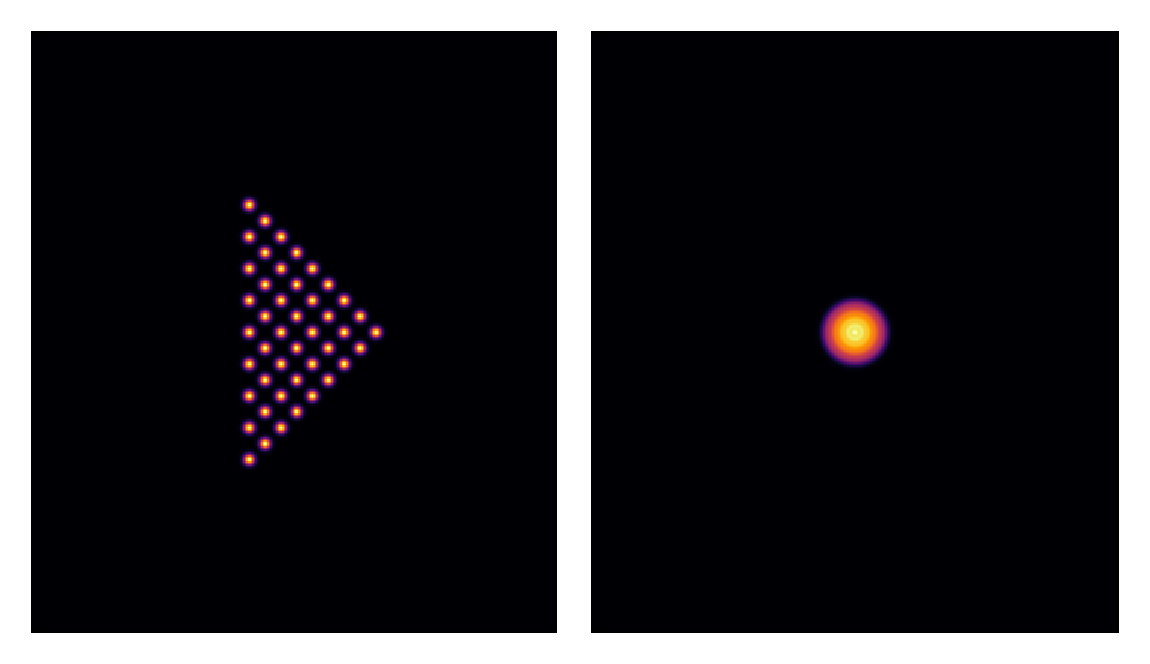

In [5]:
visualize(((u0, vf),), intensity; colormap = :inferno, height = 300)

## Optical system design

For the purpose of this tutorial, we create a fictive micro-optical system with
miniaturized dimensions and short propagation distances between successive elements
compared to the reference articles, without consideration for practical realization
of such a system. The system consists of 8 phase masks (multi-plane light conversion
with 8 planes) separated by free-space propagation.

In [6]:
z = 150.0  # Propagation distance between DOEs (arbitrary for this example)
p = ASProp(u0, z; use_cache = true)
doe() = Phase(u0; trainable = true, buffered = true)

doe (generic function with 1 method)

Create an optical system with 8 different DOEs

In [7]:
s = ScalarSource(u0)
system = (s |> p |> doe() |> p |> doe() |> p |> doe() |> p |> doe() |> p |> doe()
          |> p |> doe() |> p |> doe() |> p |> doe() |> p) |> (; inplace = true);

We propagate the input modes through the system
before optimization and visualize the total intensity:

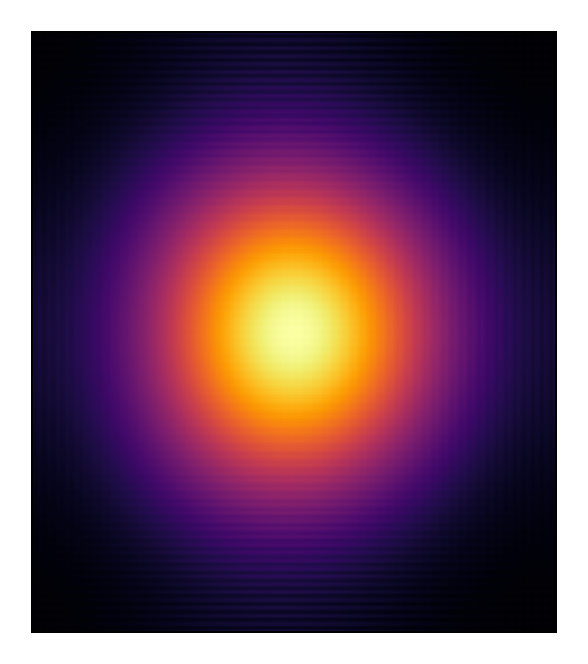

In [8]:
uf = system().out

visualize(uf, intensity; colormap = :inferno, height = 300)

Note: We observe some small aliasing for the total propagation distance. This could be
mitigated by increasing the grid size or adding an aperture stop somewhere in the
system, but for this example it doesn't significantly affect the conditioning and convergence
of the simulation.

## Loss function and optimization setup

We define the loss as the squared difference between the output field and target
field. We use FISTA with a sparsity proximal operator to promote smooth phase
distributions.

In [9]:
field_metric = SquaredFieldDifference(vf)
loss(m) = sum(field_metric(m().out));
# This is equivalent to:
# loss(m) = sum(abs2.(m().out.electric .- vf.electric))

prox = IstaProx(2e-4)  # Sparsity prox to avoid fine details at low energy
rule = ProxRule(Fista(5), prox)
opt = FluxOptics.setup(rule, system)

# Reset each DOE to zero phase before optimization
foreach(x -> isa(x, Phase) && fill!(x, 0), get_components(system));

## Optimization loop

We run 1000 iterations of gradient descent with proximal optimization.

In [10]:
_, g = withgradient(loss, system);
FluxOptics.update!(opt, system, g[1]);

losses = []
@time for iter in 1:1000
    val, grads = withgradient(loss, system)
    FluxOptics.update!(opt, system, grads[1])
    push!(losses, val)
end

 29.544389 seconds (41.01 M allocations: 2.202 GiB, 5.85% gc time)


Visualize the convergence:

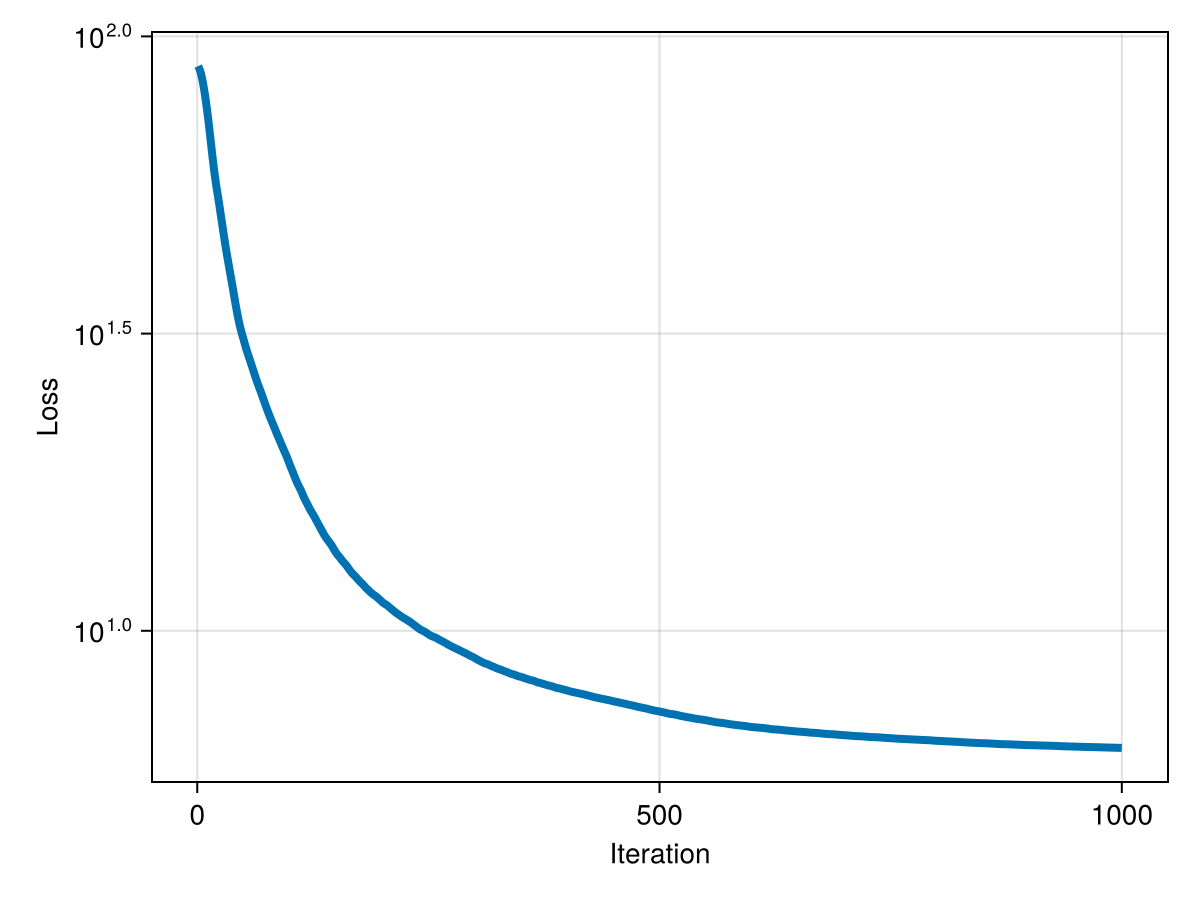

In [11]:
fig_loss = Figure()
ax = Makie.Axis(fig_loss[1, 1], yscale = log10, xlabel = "Iteration", ylabel = "Loss")
lines!(ax, losses; linewidth = 4)
fig_loss

## Results: Optimized output field

Let's visualize the total intensity of the optimized output modes compared to the targets:

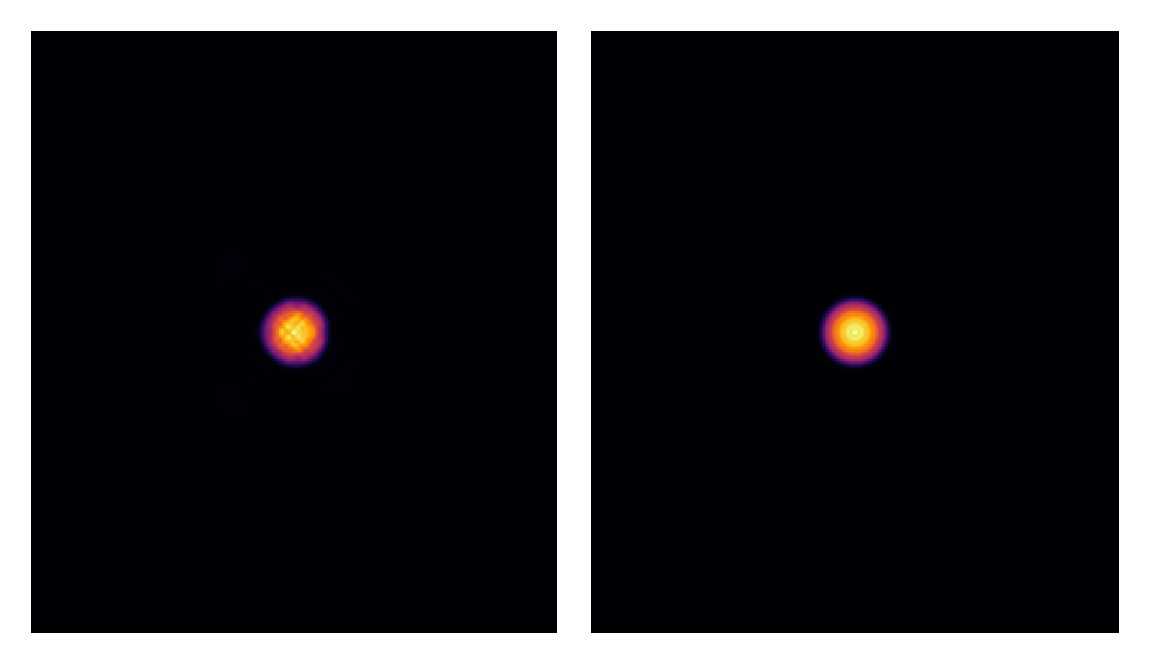

In [12]:
uf = system().out

visualize(((uf, vf),), intensity; colormap = :inferno, height = 300)

## Visualize optimized phase masks

Let's examine the phase patterns of the 8 optimized DOEs:

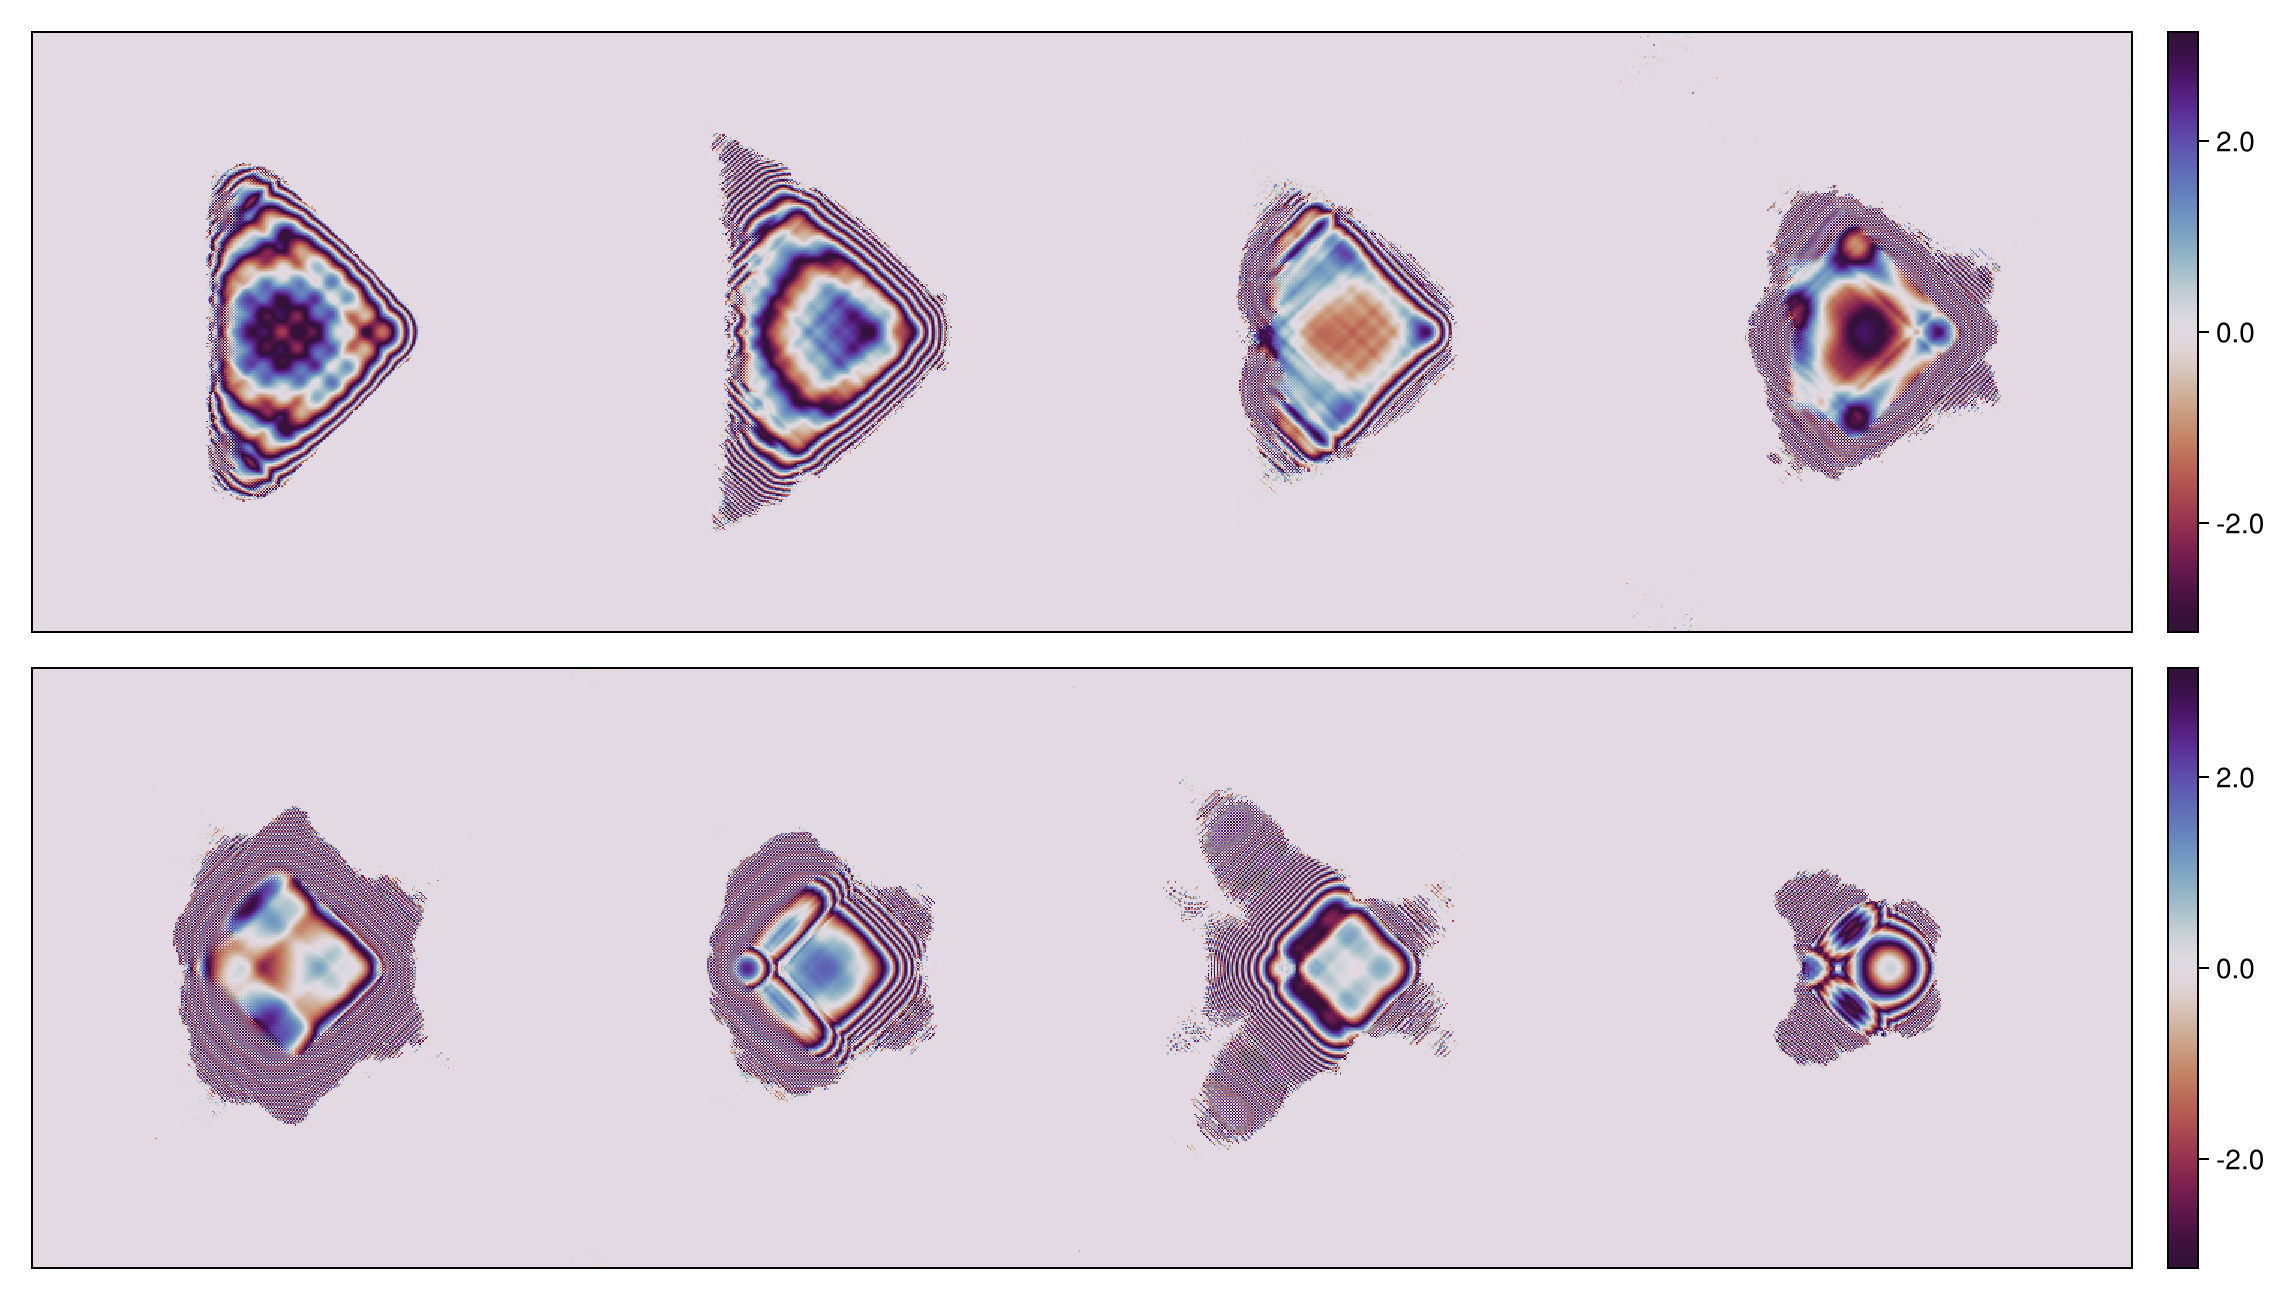

In [13]:
masks = map(x -> angle.(cis.(get_data(x))),
            filter(x -> isa(x, Phase), get_components(system)))

visualize((vcat(masks[1:4]...), vcat(masks[5:end]...)) , identity;
           colormap=:twilight_shifted, show_colorbars=true, height=300)

## Performance analysis: Mode coupling efficiency

Finally, we compute the coupling efficiency between the output and target modes
to quantify the performance of our mode sorter:

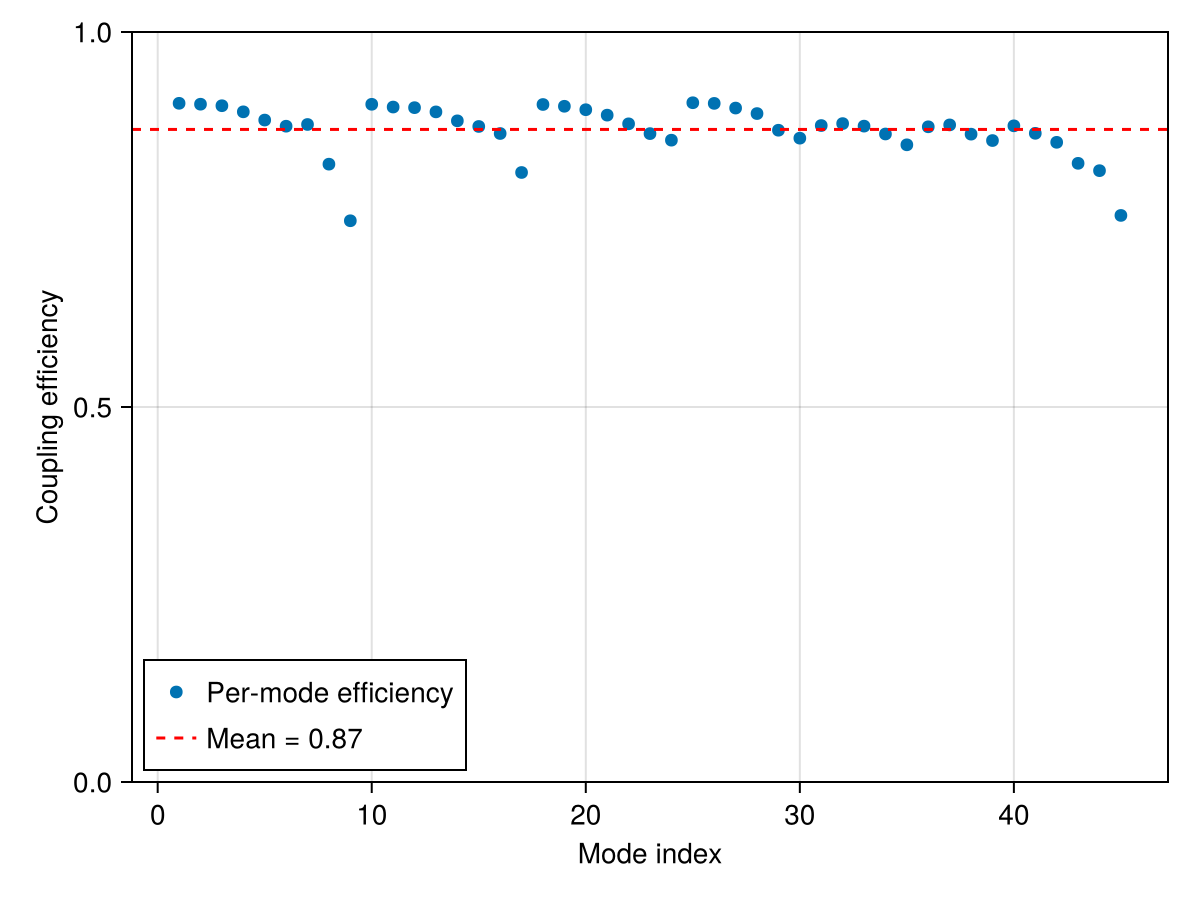

In [14]:
η = collect(coupling_efficiency(uf, vf))
η_mean = sum(η) / n_modes

fig = Figure()
ax = Axis(fig[1,1], xlabel="Mode index", ylabel="Coupling efficiency")
plot!(ax, η, label="Per-mode efficiency")
hlines!(ax, η_mean, color=:red, linestyle=:dash, label="Mean = $(round(η_mean, digits=3))")
ylims!(ax, 0, 1)
axislegend(ax, position=:lb)
fig

The mean coupling efficiency shows how well the multi-plane system transforms
the input Gaussian beams into the target Hermite-Gaussian modes. Results typically
show mean efficiency around 80-90%, with some variation depending on the regularization strength.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*